# **1. Reflection**
Reflection은 에이전트가 스스로 결과를 평가·비판 한 뒤 그 피드백을 상태(state)에 기록하고, 필요하면 수정 루프로 되돌아가 답을 개선하는 설계 패턴입니다. 보통 “작성 노드(답 생성) → 리플렉션 노드(자기평가) → 라우팅(조건부 엣지)”로 구성되며, 리플렉션 노드는 품질 기준(예: 정확성, 근거, 형식)을 점수·코멘트(score, critique)로 남깁니다. 라우터는 이 정보를 읽어 임계값 미달이면 작성 노드로 되감기, 충족하면 종료 노드로 이동합니다. 무한 루프를 막기 위해 max_iters 같은 반복 한도를 두며, 툴 호출과는 별개로 LLM의 자기검토 능력을 활용해 코드 생성, 질의응답, 체인드 리저닝 등의 정확도·일관성을 높이는 데 쓰입니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fet5eoq%2FbtsQtfTBoz7%2FAAAAAAAAAAAAAAAAAAAAAM6C44vgBF-5pX8AStDskIMKM2c-gg9io9wsDgxh0NT0%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D5r2AoFcs9RsXoictxR7M800sVgA%253D'>

In [1]:
import getpass
import os

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

OPENAI_API_KEY: ··········


In [2]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 2.6 MB/s eta 0:00:00


# **2. LangChain + OpenAI 모델을 이용한 노래 가사쓰기**

- 가사 생성기: 사용자 요청을 받아 5단락 가사를 생성
- 가사 평가기
    - 만들어진 가사를 읽고 잘된 점
    - 아쉬운 점
    - 수정 지시사항 등을 만듦
- 가사 수정기: 평가 내용을 다시 생성기에게 주고, 이전 가사를 더 좋게 고쳐서 새 버전을 만듦

> 단순히 한 번만 생성하는 것이 아니라, 한 번 생성한 결과를 다시 비판하고 개선하는 구조


### 1. 생성 프롬프트

In [ ]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

In [ ]:
# ChatPromptTemplate: 채팅형 프롬프트를 만드는 툴. system, human, ai 같은 메시지 구조를 쉽게 만들 수 있음
# from_messages: 메시지 목록으로 프롬프트를 구성

# MessagesPlaceholder: 나중에 실제 대화 메시지들이 들어갈 자리
prompt = ChatPromptTemplate.from_messages(
    [
        ("system",
            "당신은 5단락 노래 가사를 작성하는 작사 도우미입니다. "
            "사용자의 요청에 맞게 주제, 분위기, 감정을 반영한 가사를 작성하세요. "
            "좋은 가사는 감정이 자연스럽게 이어지고, 표현이 구체적이며, 전체 흐름이 일관되어야 합니다. "
            "사용자가 피드백을 제공하면, 이전 결과를 그대로 반복하지 말고 "
            "지적된 부분이 눈에 띄게 개선된 수정본을 작성하세요. "
            "이때 잘된 표현과 핵심 주제는 유지하고, 감정 표현, 문장 자연스러움, 이미지 표현을 더 좋게 다듬으세요. "
            "반드시 5단락으로 작성하고, 각 단락은 명확히 구분하세요."),
        MessagesPlaceholder(variable_name='messages')
    ]
)

In [ ]:
llm = ChatOpenAI(model='gpt-5.4-2026-03-05')
generate = prompt | llm

### 2. 평가 프롬프트

In [ ]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 노래 가사를 평가하고 개선 방향을 제안하는 작사 코치입니다. "
            "사용자가 제출한 가사를 읽고 주제의 일관성, 감정의 깊이, 표현의 구체성, "
            "문체의 자연스러움, 단락 간 흐름을 기준으로 평가하세요. "
            "응답은 반드시 다음 세 부분으로 작성하세요. "
            "1. 잘된 점 "
            "2. 아쉬운 점 "
            "3. 수정 지시사항 "
            "수정 지시사항은 다음 작사 단계에서 바로 반영할 수 있을 만큼 구체적으로 작성하세요."
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

reflect = reflection_prompt | llm

### 3. 사용자 요청

In [ ]:
request = HumanMessage(content='이별에 대한 가사를 작성해줘.')

### 4. 초안 생성

In [ ]:
draft_lyrics = ""
for chunk in generate.stream({"messages": [request]}):
    if chunk.content:
        print(chunk.content, end='')
        draft_lyrics += chunk.content

print("\n\n[초안 가사]")
print(draft_lyrics)

1.
문득 멈춘 듯한 저녁 골목 끝에서  
너와 걷던 발자국을 혼자 따라가  
익숙한 향기처럼 남아 있는 기억은  
다 지운 줄 알았는데 또 날 붙잡아  
차가운 바람 사이로 네 이름이 번져

2.
아무렇지 않은 척 웃어 보려 해도  
텅 빈 내 맘은 자꾸 너를 찾아 헤매  
함께 듣던 노래가 거리에서 들리면  
애써 감춘 그리움이 다시 고개를 들어  
끝난 이야기인데 난 아직 그 안에 서 있어

3.
우리 사랑은 왜 이렇게 쉽게 멀어졌을까  
작은 오해 하나도 아프게 남아서  
붙잡고 싶던 순간마다 늦어버린 말들  
이젠 돌아갈 수 없단 걸 알면서도  
나는 아직 그날의 너를 놓지 못해

4.
밤이 깊어질수록 더 선명해지는 건  
이별보다 따뜻했던 너의 마지막 온기  
잊어야 한다는 말은 너무 쉬운데  
내 하루는 아직도 너로 가득 차 있어서  
지우려 할수록 더 짙게 번져만 가

5.
언젠가는 이 아픔도 무뎌질 거라고  
스스로를 달래며 또 하루를 버텨내  
너 없는 내일이 낯설지 않은 날엔  
그땐 웃으며 너를 추억할 수 있을까  
오늘은 아직 아니야, 너무 그리우니까

[초안 가사]
1.
문득 멈춘 듯한 저녁 골목 끝에서  
너와 걷던 발자국을 혼자 따라가  
익숙한 향기처럼 남아 있는 기억은  
다 지운 줄 알았는데 또 날 붙잡아  
차가운 바람 사이로 네 이름이 번져

2.
아무렇지 않은 척 웃어 보려 해도  
텅 빈 내 맘은 자꾸 너를 찾아 헤매  
함께 듣던 노래가 거리에서 들리면  
애써 감춘 그리움이 다시 고개를 들어  
끝난 이야기인데 난 아직 그 안에 서 있어

3.
우리 사랑은 왜 이렇게 쉽게 멀어졌을까  
작은 오해 하나도 아프게 남아서  
붙잡고 싶던 순간마다 늦어버린 말들  
이젠 돌아갈 수 없단 걸 알면서도  
나는 아직 그날의 너를 놓지 못해

4.
밤이 깊어질수록 더 선명해지는 건  
이별보다 따뜻했던 너의 마지막 온기  
잊어야 한다는 말은 너무 쉬운데  
내 하루는 아직도 너로 가득 차 있어서  
지우려 할수록 더 짙게 번

### 5. 피드백 생성

In [ ]:
reflection_feedback = ""
for chunk in reflect.stream({
    "messages": [
        request,
        AIMessage(content=draft_lyrics)
    ]
}):
    if chunk.content:
        print(chunk.content, end='')
        reflection_feedback += chunk.content
print("\n\n[피드백]")
print(reflection_feedback)

1. 잘된 점  
- 이별 직후의 그리움과 공허함을 누구나 공감하기 쉬운 정서로 잘 잡았습니다.  
- “저녁 골목”, “함께 듣던 노래”, “마지막 온기”처럼 이별의 정서를 떠올리게 하는 소재가 자연스럽게 들어가 있습니다.  
- 전체적으로 감정선이 안정적입니다. 억지로 극적인 전개를 만들기보다, 아직 잊지 못한 상태를 끝까지 유지해서 주제가 일관됩니다.  
- 문장이 전반적으로 부드럽고 가사체로 읽었을 때 무난하게 흘러갑니다.  

2. 아쉬운 점  
- 표현이 다소 익숙하고 보편적입니다. “텅 빈 내 맘”, “너를 찾아 헤매”, “놓지 못해”, “너무 그리우니까” 같은 구절은 많이 쓰이는 표현이라 인상에 강하게 남는 한 방이 약합니다.  
- 감정은 충분히 전달되지만, 화자만의 사연이나 관계의 디테일은 부족합니다. 그래서 “이별 노래”로는 잘 작동하지만, “이 사람의 이별”이라는 개성이 선명하지는 않습니다.  
- 각 연이 비슷한 정서와 방식으로 전개되어서 중반 이후에는 약간 평평하게 느껴질 수 있습니다.  
- 후렴처럼 반복해 기억에 남길 만한 핵심 문장이나 상징이 아직 없습니다.  

3. 수정 지시사항  
- 한 줄짜리 핵심 후렴을 먼저 정하세요. 예: “끝난 계절에 나만 아직 서 있어”처럼 곡 전체를 대표할 문장을 1개 만들고, 2~3번 반복되게 구성하세요.  
- 추상어를 줄이고 구체적인 장면을 3개 이상 넣으세요. 예: “텅 빈 내 맘” 대신 “네가 벗어 둔 회색 후드가 아직 소파 끝에 걸려 있어”처럼 실제 사물이 보이게 쓰세요.  
- 이별의 원인이나 둘의 관계를 드러내는 단서 1개를 넣으세요. 예: 잦은 다툼, 말하지 못한 진심, 늦은 연락, 계절의 변화 등. 그래야 감정의 설득력이 커집니다.  
- 각 연의 역할을 분명히 나누세요.  
  - 1절: 이별 후 남겨진 현재 장면  
  - 2절: 함께했던 구체적 기억  
  - 브리지: 왜 끝났는지에 대한 후회  
  - 후렴: 아직 잊지 못한다는 핵심 감정  
- 상투적인 표현은 더 새로운

### 6. 수정본 생성

In [ ]:
revised_lyrics = ""
revision_request = HumanMessage(
    content=(
        "아래 피드백을 반드시 반영하여 이전 가사를 수정해주세요. "
        "원문을 그대로 반복하지 말고, 표현과 감정을 더 풍부하게 개선해주세요.\n\n"
        f"{reflection_feedback}"
    )
)

for chunk in generate.stream({
    "messages": [
        request,
        AIMessage(content=draft_lyrics),
        revision_request
    ]
}):
    if chunk.content:
        print(chunk.content, end='')
        revised_lyrics += chunk.content

print("\n\n[수정본 가사]")
print(revised_lyrics)

1.
현관 앞에 벗어 둔 네 회색 후드가  
며칠째 같은 모양으로 소파 끝에 걸려 있어  
식탁 위엔 반쯤 마신 자몽에이드 자국,  
네가 쓰다 놓고 간 머그컵 손잡이엔 금이 갔고  
끝난 계절에 나만 아직 서 있어

2.
비 오던 토요일, 네 우산은 늘 내 쪽으로 기울었지  
젖은 운동화 끈을 묶어 주던 네 손이 이상하게 느렸고  
심야 버스 맨 뒷자리, 창문에 김 서리면  
넌 손가락으로 내 이름 끝 글자만 작게 쓰곤 했어  
지금도 무심코 네가 내릴 정류장에 눈이 멈춰

3.
우린 크게 부서진 게 아니라 조금씩 늦어졌어  
답장 없는 밤이 쌓이고, 미뤄 둔 미안해가 버릇이 됐지  
붙잡아야 할 순간마다 나는 괜찮은 척을 먼저 골랐고  
지운 번호를 손가락만 먼저 기억해  
끝난 계절에 나만 아직 서 있어

4.
편의점 불빛 아래 서서 2인분 삼각김밥을 집다가  
아, 이제 하나만 사면 된다는 걸 뒤늦게 배워  
함께 듣던 노래보다 더 선명한 건  
네가 웃으며 “늦었다” 말하던 새벽 한 시의 목소리  
오늘은 네 이름 한 번에도 밤이 길어지니까

5.
창틀에 말라붙은 화분 잎을 하나씩 떼어 내며  
나도 조금은 지난 계절을 정리해 보려 해  
아직 네가 남긴 습관들 사이를 돌아 걷지만  
언젠가 이 거리의 바람이 덜 차갑게 느껴지는 날,  
끝난 계절에 나만 아직 서 있어, 그 문장에서도 조금은 벗어나겠지

[수정본 가사]
1.
현관 앞에 벗어 둔 네 회색 후드가  
며칠째 같은 모양으로 소파 끝에 걸려 있어  
식탁 위엔 반쯤 마신 자몽에이드 자국,  
네가 쓰다 놓고 간 머그컵 손잡이엔 금이 갔고  
끝난 계절에 나만 아직 서 있어

2.
비 오던 토요일, 네 우산은 늘 내 쪽으로 기울었지  
젖은 운동화 끈을 묶어 주던 네 손이 이상하게 느렸고  
심야 버스 맨 뒷자리, 창문에 김 서리면  
넌 손가락으로 내 이름 끝 글자만 작게 쓰곤 했어  
지금도 무심코 네가 내릴 정류장에 눈이 멈춰

3.
우린 크게 부서진 게 아니라 조금씩 늦어졌어  
답장 

# **3. Graph로 Reflection 구현**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FKZUhB%2FbtsQxetHmFz%2FAAAAAAAAAAAAAAAAAAAAAP0EuRkgL4J0CjrSQh0IKSN45ducYKse-WsdmcfUNwRn%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D3cXJM7xKKk5DHhdc95Azms6C9N4%253D'>

In [ ]:
!pip install langgraph

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
def generation_node(state: State) -> State:
    return {"messages": [generate.invoke(state['messages'])]}

In [ ]:
def reflection_node(state: State) -> State:
    cls_map = {"ai": AIMessage, "human": HumanMessage}
    # state['messages'][0]: 첫 번째 메시지(최초 사용자 요청)
    # state['messages'][1:]: 두 번째 메시지부터 끝까지(생성된 가사, 피드백, 수정본, 다시 피드백 ...)
    # msg.type: ai, human
    # cls_map[msg.type](content=msg.content): ai면 AIMessage(content...), human이면 HumanMessage(content...)
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    res = reflect.invoke(translated)
    return {"messages": [HumanMessage(content=res.content)]}

In [ ]:
graph_builder = StateGraph(State)
graph_builder.add_node("generate", generation_node)
graph_builder.add_node("reflect", reflection_node)
graph_builder.add_edge(START, "generate")

In [ ]:
from typing import Literal
from langgraph.graph import END

In [ ]:
def should_continue(state: State) -> Literal["reflect", END]:
    if len(state["messages"]) > 6:
        return END
    return "reflect"

graph_builder.add_conditional_edges("generate", should_continue)

In [ ]:
graph_builder.add_edge("reflect", "generate")

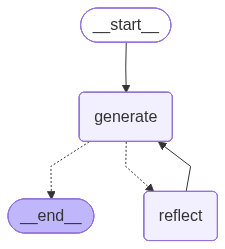

In [ ]:
# 메모리 기반 체크포인터 객체를 생성
# checkpointer=memory: 상태 저장 기능도 연결
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [ ]:
# thread_id: 체크포인터 사용할 때는 어떤 실행 흐름의 상태인지 구분이 필요함
# thread_id = "1" : 첫 번째 대화 흐름
# thread_id = "2" : 다른 대화 흐름
# 같은 그래프라도 thread_id가 다르면 서로 다른 상태를 가질 수 있음
config = {"configurable": {"thread_id": "1"}}

In [ ]:
for event in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="이별에 대한 가사를 작성해주세요."
            )
        ]
    },
    config
):
    print(event)
    print("-" * 30)

{'generate': {'messages': [AIMessage(content='1.\n네가 떠난 자리엔 아직\n미처 닫지 못한 계절이 남아\n식어버린 커피잔 끝에\n우리의 시간이 고요히 맺혀 있어\n\n2.\n아무렇지 않은 척 웃어도\n익숙한 골목마다 네가 서 있고\n스쳐 가는 바람 한 줄기에도\n참았던 그리움이 다시 날 흔들어\n\n3.\n이별은 생각보다 조용히 와서\n한마디 인사도 없이 날 무너뜨리고\n텅 빈 방 안에 남겨진 나는\n늦은 후회들만 세어 보게 돼\n\n4.\n사랑했던 날들은 선명한데\n왜 끝은 이렇게 흐려져 가는지\n붙잡지 못한 내 두 손 사이로\n너는 추억이 되어 멀어져만 가\n\n5.\n언젠가 이 아픔도 지나가겠지만\n오늘은 아직 네 이름이 시려\n보내야 한다는 걸 알면서도\n나는 한동안 이별 속에 살 것 같아', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 238, 'prompt_tokens': 182, 'total_tokens': 420, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DLTNioYTZEeBA1wqCZx9IOczJ12BD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0b3f-75

In [ ]:
state = graph.get_state(config)
state

StateSnapshot(values={'messages': [HumanMessage(content='이별에 대한 가사를 작성해주세요.', additional_kwargs={}, response_metadata={}, id='71fcb3e9-1e66-46b4-880f-a629f12d6238'), AIMessage(content='1.\n네가 떠난 자리엔 아직\n미처 닫지 못한 계절이 남아\n식어버린 커피잔 끝에\n우리의 시간이 고요히 맺혀 있어\n\n2.\n아무렇지 않은 척 웃어도\n익숙한 골목마다 네가 서 있고\n스쳐 가는 바람 한 줄기에도\n참았던 그리움이 다시 날 흔들어\n\n3.\n이별은 생각보다 조용히 와서\n한마디 인사도 없이 날 무너뜨리고\n텅 빈 방 안에 남겨진 나는\n늦은 후회들만 세어 보게 돼\n\n4.\n사랑했던 날들은 선명한데\n왜 끝은 이렇게 흐려져 가는지\n붙잡지 못한 내 두 손 사이로\n너는 추억이 되어 멀어져만 가\n\n5.\n언젠가 이 아픔도 지나가겠지만\n오늘은 아직 네 이름이 시려\n보내야 한다는 걸 알면서도\n나는 한동안 이별 속에 살 것 같아', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 238, 'prompt_tokens': 182, 'total_tokens': 420, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id

In [ ]:
ChatPromptTemplate.from_messages(state.values['messages']).pretty_print()

================================ Human Message =================================

이별에 대한 가사를 작성해주세요.

================================== Ai Message ==================================

1.
네가 떠난 자리엔 아직
미처 닫지 못한 계절이 남아
식어버린 커피잔 끝에
우리의 시간이 고요히 맺혀 있어

2.
아무렇지 않은 척 웃어도
익숙한 골목마다 네가 서 있고
스쳐 가는 바람 한 줄기에도
참았던 그리움이 다시 날 흔들어

3.
이별은 생각보다 조용히 와서
한마디 인사도 없이 날 무너뜨리고
텅 빈 방 안에 남겨진 나는
늦은 후회들만 세어 보게 돼

4.
사랑했던 날들은 선명한데
왜 끝은 이렇게 흐려져 가는지
붙잡지 못한 내 두 손 사이로
너는 추억이 되어 멀어져만 가

5.
언젠가 이 아픔도 지나가겠지만
오늘은 아직 네 이름이 시려
보내야 한다는 걸 알면서도
나는 한동안 이별 속에 살 것 같아

================================ Human Message =================================

1. 잘된 점  
- 이별의 정서를 안정적으로 담아냈습니다.  
- “식어버린 커피잔”, “텅 빈 방”, “익숙한 골목” 같은 이미지가 이별 후의 공허함을 잘 전달합니다.  
- 전체적으로 감정선이 차분하게 이어져서 발라드 가사로 쓰기 좋은 분위기가 있습니다.  
- 후렴처럼 사용할 수 있는 문장들, 예를 들면 “이별은 생각보다 조용히 와서” 같은 구절은 인상에 남습니다.

2. 아쉬운 점  
- 표현이 전반적으로 익숙하고 무난해서, 이 가사만의 개성이 강하게 드러나지는 않습니다.  
- 감정은 잘 보이지만, “왜 이별했는지”, “상대와 어떤 관계였는지” 같은 구체적 배경이 부족해 몰입감이 조금 약합니다.  
- 각 연이 비슷한 톤과 방식으로 슬픔을 반복하고 있어서, 후반으로 갈수록 새로운

# **4. Reflextion 구현**
[“Reflexion: Language Agents with Verbal Reinforcement Learning”](https://arxiv.org/pdf/2303.11366)은, 2023년 3월 20일 최초 제출, 2023년 10월 10일 v4로 개정된 논문입니다. 저자는 Noah Shinn 외 5명이고, 핵심 내용은 언어 에이전트가 스스로 언어적 피드백(반성문)을 생성·메모리에 저장해 다음 시도에 반영함으로써 성능을 높이는 프레임워크를 제안했다는 점입니다. HumanEval 등에서 유의미한 향상을 보고합니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fdzon1Q%2FbtsQxdO7zsM%2FAAAAAAAAAAAAAAAAAAAAAIv8GnJo2Z7lQar4RlJWoaap2PH03wadiph8ot4leqkE%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DYLvIQazd8nfTlqgPYHLcJHzHcpY%253D'>

* Actor (LM): 실제 행동(답안 작성, 코드 생성 등)을 내는 언어모델입니다.
* Evaluator (LM): Actor가 낸 결과를 내부적으로 평가합니다(정확성·형식·테스트 통과 여부 판단 등).
* Self-reflection (LM): 평가 결과를 바탕으로 “다음에는 이렇게 고치자” 같은 반성문(Reflective text)을 만들어 냅니다.
* Trajectory (short-term memory): 이번 시도에서의 행동/관찰 기록(a₀, o₀, …)을 담는 단기 메모리입니다.
* Experience (long-term memory): 누적된 반성문을 쌓아두는 장기 메모리(mem)입니다. 이후 시도에서 프롬프트에 이 기억을 넣어 같은 실수를 반복하지 않게 합니다.
* Environment: 외부에서 관찰/보상(예: 유닛 테스트의 통과/실패, 웹툴의 응답 등)을 제공합니다. 외부 피드백이 있으면 Evaluator의 판단과 함께 사용됩니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fmii1M%2FbtsQzJFXs6L%2FAAAAAAAAAAAAAAAAAAAAABlDou97baB3Ry75PiiSdFP4Aml0fM58iNNa5PCw8tAm%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DOKARG8790LTTUc0w9eiUkPnOHF4%253D'>

In [30]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [31]:
from langchain_openai import ChatOpenAI

In [32]:
llm = ChatOpenAI(model="gpt-5.4-2026-03-05")

In [33]:
!pip install langchain_community langchain-tavily

In [57]:
from langchain_tavily import TavilySearch

In [58]:
tavily_tool = TavilySearch(max_results=5)

### 1. 필요한 데이터 클래스 정의

In [59]:
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field

In [60]:
class Reflection(BaseModel):
    missing: str = Field(description="누락되거나 부족한 부분에 대한 비평")
    superflous: str = Field(description="불필요한 부분에 대한 비평")

In [61]:
class AnswerQuestion(BaseModel):
    answer: str = Field(description="질문에 대한 10문장 이내의 자세한 답변")
    search_queries: list[str] = Field(description="현재 답변에 대한 비평을 해결하기 위해 추가 조사를 위한 1~3개의 웹 검색 쿼리")
    reflection: Reflection = Field(description="답변에 대한 자기반성 내용")

In [62]:
class Responder:
    def __init__(self, runnable):
        self.runnable = runnable

    def respond(self, state: dict):
        response = self.runnable.invoke(
            {"messages": state["messages"]}
        )
        return {"messages": response}

### 2. 초기 답변기 만들기

In [63]:
actor_prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 전문 연구자입니다.

            1. {first_instruction}
            2. <Reflect> 생성한 답변을 다시 되돌아보고 개선할 수 있도록 비판하세요.
            3. <Recommend search queries> 답변의 질을 높이기 위해 추가적으로 조사해야 할 정보에 대한 웹 검색 쿼리를 추천하세요.""",
        ),
        MessagesPlaceholder(variable_name='messages'),
        (
            "user",
            "\n\n<Reflect> 사용자 원래 질문과 지금까지의 행동을 되돌아보세요."
        )
    ]
)

In [64]:
# 프롬프트를 만듦
# 프롬프트를 LLM에 넣음
# LLM은 AnswerQuestion 구조에 맞는 결과를 반환
initial_answer_chain = actor_prompt_template.partial(
    first_instruction="질문에 대한 10문장 이내의 자세한 답변을 제공해주세요."
) | llm.bind_tools(tools=[AnswerQuestion], tool_choice="any")

In [65]:
llm_with_tool = llm.bind_tools(tools=[AnswerQuestion], tool_choice='any')
response = llm_with_tool.invoke([HumanMessage(content="AI Agent가 무엇인가요?")])
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 398, 'prompt_tokens': 218, 'total_tokens': 616, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DMXmBgCQWqHtHaCGp9jWNfOPAtNSw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1a75-d40c-71b1-8b70-a141372947e6-0', tool_calls=[{'name': 'AnswerQuestion', 'args': {'answer': 'AI Agent는 목표를 달성하기 위해 스스로 상황을 인식하고, 판단하고, 행동하는 인공지능 시스템입니다. 단순히 질문에 답하는 챗봇과 달리, 에이전트는 주어진 목표에 따라 여러 단계를 계획하고 실행할 수 있습니다. 예를 들어 정보를 검색하고, 필요한 도구를 호출하고, 결과를 바탕으로 다음 행동을 결정할 수 있습니다. 보통 AI Agent는 입력을 이해하는 모델, 의사결정 로직, 메모리, 그리고 외부 도구와 연결되는 기능으로 구성됩니다. 사람의 지시를 한 번 받고도 중간 과정을 자율적으로 처리하는 점이 핵심 특징입니다. 예를 들어 여행

In [66]:
response.tool_calls[0]['args']

{'answer': 'AI Agent는 목표를 달성하기 위해 스스로 상황을 인식하고, 판단하고, 행동하는 인공지능 시스템입니다. 단순히 질문에 답하는 챗봇과 달리, 에이전트는 주어진 목표에 따라 여러 단계를 계획하고 실행할 수 있습니다. 예를 들어 정보를 검색하고, 필요한 도구를 호출하고, 결과를 바탕으로 다음 행동을 결정할 수 있습니다. 보통 AI Agent는 입력을 이해하는 모델, 의사결정 로직, 메모리, 그리고 외부 도구와 연결되는 기능으로 구성됩니다. 사람의 지시를 한 번 받고도 중간 과정을 자율적으로 처리하는 점이 핵심 특징입니다. 예를 들어 여행 계획을 짜거나, 이메일을 분류하거나, 고객 문의를 자동 처리하는 시스템이 AI Agent의 형태가 될 수 있습니다. 최근에는 생성형 AI와 결합되어 더 자연스럽고 복잡한 작업도 수행할 수 있게 되었습니다. 다만 완전히 스스로 판단하게 하면 오류나 예기치 않은 행동이 생길 수 있어, 보통은 권한 제한과 검토 절차를 함께 둡니다. 즉, AI Agent는 ‘대답만 하는 AI’가 아니라 ‘목표를 위해 행동하는 AI’라고 이해하면 쉽습니다.',
 'search_queries': ['AI Agent 정의와 특징', '챗봇과 AI Agent 차이', 'AI 에이전트 구성 요소 예시'],
 'reflection': {'missing': '정의와 예시는 포함했지만, 좁은 의미의 소프트웨어 에이전트와 넓은 의미의 자율 시스템 차이를 더 명확히 설명할 수 있습니다.',
  'superflous': '초보자 설명에는 권한 제한과 검토 절차 부분이 약간 부가적으로 느껴질 수 있습니다.'}}

In [67]:
first_responder = Responder(runnable=initial_answer_chain)

In [68]:
example_question = "AI Agent가 무엇인가요?"
initial = first_responder.respond(
    {"messages": [HumanMessage(content=example_question)]}
)

In [69]:
initial

{'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 438, 'prompt_tokens': 335, 'total_tokens': 773, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DMXmJsjjeyXJ3eJQUGt9IZURrDdAL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1a75-f2b3-77d2-acbf-533c3d7ead8e-0', tool_calls=[{'name': 'AnswerQuestion', 'args': {'answer': 'AI Agent는 주어진 목표를 달성하기 위해 환경을 인식하고, 판단하며, 행동을 수행하는 인공지능 시스템입니다. 단순히 질문에 답하는 모델과 달리, AI Agent는 여러 단계의 계획을 세우고 외부 도구나 데이터베이스, API를 활용해 실제 작업을 수행할 수 있습니다. 예를 들어 일정 예약, 문서 요약 후 이메일 발송, 웹 정보 수집과 같은 연속적인 업무를 스스로 처리할 수 있습니다. 핵심 구성 요소로는 목표 설정, 상태 추적, 의사결정, 도구 사용, 그리고 결과 평가가 포함됩니다. 최근의 AI Agent는 대

In [70]:
initial['messages'].tool_calls[0]['args']

{'answer': 'AI Agent는 주어진 목표를 달성하기 위해 환경을 인식하고, 판단하며, 행동을 수행하는 인공지능 시스템입니다. 단순히 질문에 답하는 모델과 달리, AI Agent는 여러 단계의 계획을 세우고 외부 도구나 데이터베이스, API를 활용해 실제 작업을 수행할 수 있습니다. 예를 들어 일정 예약, 문서 요약 후 이메일 발송, 웹 정보 수집과 같은 연속적인 업무를 스스로 처리할 수 있습니다. 핵심 구성 요소로는 목표 설정, 상태 추적, 의사결정, 도구 사용, 그리고 결과 평가가 포함됩니다. 최근의 AI Agent는 대규모 언어모델을 두뇌처럼 활용하면서도, 메모리와 실행 모듈을 결합해 더 복합적인 문제를 해결합니다. 따라서 AI Agent는 단순 챗봇보다 더 자율적이고 작업 지향적이라는 점이 특징입니다. 다만 완전한 자율성에는 여전히 한계가 있어, 잘못된 판단이나 부정확한 도구 사용을 막기 위해 사람의 감독이 필요한 경우가 많습니다. 결국 AI Agent는 ‘생각-계획-행동-검토’의 흐름을 반복하며 목표를 달성하는 지능형 실행 주체라고 볼 수 있습니다.',
 'search_queries': ['AI agent definition vs chatbot',
  'LLM-based AI agent architecture',
  'AI agent examples task planning tool use'],
 'reflection': {'missing': '사용자 질문은 기본 개념 설명을 요구하므로 충분히 답했지만, AI Agent의 종류(반응형, 목표기반형, 자율형)나 실제 산업 적용 사례를 더 넣으면 이해가 깊어질 수 있습니다.',
  'superflous': '현재 답변은 비교적 간결하며 불필요한 부분은 많지 않지만, 대규모 언어모델과 메모리 구조 설명은 입문자에게는 약간 추상적으로 느껴질 수 있습니다.'}}

### 3. 수정 단계

In [71]:
class ReviseAnswer(AnswerQuestion):
    """Revise your original answer to your question. Provide an answer, reflection,

    cite your reflection with references, and finally
    add search queries to improve the answer."""

    references: list[str] = Field(description='업데이트된 답변에 사용된 인용 출처')

In [77]:
# 수정 단계에서 사용할 지시문
revise_instructions = """이전 답변을 새로운 정보를 바탕으로 수정하세요.
- 이전 비평 내용을 활용해 중요한 정보를 추가해야 합니다.
  - 수정된 답변에는 반드시 숫자로 된 인용 표시를 포함하여 검증 가능하도록 해야 합니다.
  - 답변 하단에 "참고문헌" 섹션을 추가하세요 (이 부분은 단어 수 제한에 포함되지 않습니다). 형식은 다음과 같습니다:
    - [1] https://example.com
    - [2] https://example.com

- 이전 비평 내용을 바탕으로 불필요한 정보를 제거하고, 최종 답변은 반드시 200자를 넘지 않도록 하세요.
"""

revision_chain = actor_prompt_template.partial(
    first_instruction = revise_instructions
) | llm.bind_tools(tools=[ReviseAnswer], tool_choice="any")

revisor = Responder(runnable=revision_chain)

In [78]:
import json

In [81]:
revised = revisor.respond(
    {
        "messages": [
            HumanMessage(content=example_question),
            # 앞 단계에서 생성된 초기 답변 메시지
            initial['messages'],
            # response.tool_calls[0]['id']
            ToolMessage(
                tool_call_id=initial['messages'].tool_calls[0]['id'],
                content=json.dumps(
                    tavily_tool.invoke(
                        {
                            "query": initial['messages'].tool_calls[0]['args']['search_queries'][0]
                        }
                    )
                )

            )
        ]
    }
)

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FnMKU1%2FbtsQwRziUZl%2FAAAAAAAAAAAAAAAAAAAAAASlhE2QFrMfwp2mVpfbJqW1PV9_JrnKxfrPSLouN6QH%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DTy2ZJklv8PUca0y%252FmQR9PTDcOP4%253D'>

In [82]:
revised['messages']

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 224, 'prompt_tokens': 2050, 'total_tokens': 2274, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1536}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DMXuqt4rVidHPqD42jajtPU33cIqc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1a7e-074f-70b1-973a-1b4e5dbecbc6-0', tool_calls=[{'name': 'ReviseAnswer', 'args': {'answer': 'AI Agent는 목표를 인식·계획·행동해 작업을 수행하는 시스템입니다[1]. 챗봇보다 자율성이 높고 API·도구를 써 실제 업무를 처리합니다[1][2].', 'search_queries': ['AI agent definition authoritative source', 'AI agent vs chatbot official documentation'], 'reflection': {'missing': '원래 질문은 정의 중심이므로, 핵심 차이점만 짧게 제시하면 충분합니다. 다만 권위 있는 출처를 더 보강하면 검증성이 높아집니다.',

In [83]:
revised['messages'].tool_calls

[{'name': 'ReviseAnswer',
  'args': {'answer': 'AI Agent는 목표를 인식·계획·행동해 작업을 수행하는 시스템입니다[1]. 챗봇보다 자율성이 높고 API·도구를 써 실제 업무를 처리합니다[1][2].',
   'search_queries': ['AI agent definition authoritative source',
    'AI agent vs chatbot official documentation'],
   'reflection': {'missing': '원래 질문은 정의 중심이므로, 핵심 차이점만 짧게 제시하면 충분합니다. 다만 권위 있는 출처를 더 보강하면 검증성이 높아집니다.',
    'superflous': '이전 답변의 메모리·구조 설명과 예시는 입문 정의에 비해 다소 장황했습니다. 이번에는 핵심 정의와 챗봇 대비 차이만 남기는 것이 적절합니다.'},
   'references': ['https://www.digitalocean.com/resources/articles/ai-agent-vs-ai-chatbot',
    'https://www.salesforce.com/agentforce/ai-agent-vs-chatbot/']},
  'id': 'call_WcwGhtLcEnkJT7dz4usNOeR3',
  'type': 'tool_call'}]

### 4. 웹검색을 위한 툴 노드 생성

In [84]:
# batch: 여러 개의 검색 요청을 한 번에 실행하는 함수
tavily_tool.batch(
    [
        # AIMessage객체 -> 모델이 호출한 첫 번째 tool(AnswerQuestion 결과) ->
        # 툴에 전달된 실제 데이터 -> 모델이 추천한 검색어 중 첫 번째만 선택
        {'query': initial['messages'].tool_calls[0]['args']['search_queries'][0]}
    ]
)

[{'query': 'AI agent definition vs chatbot',
  'response_time': 0.79,
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://www.digitalocean.com/resources/articles/ai-agent-vs-ai-chatbot',
    'title': 'AI Agent vs AI Chatbot: Key Differences Explained - DigitalOcean',
    'content': 'An AI agent is a more advanced artificial intelligence system capable of performing complex tasks and making decisions with minimal human guidance.',
    'score': 0.99996495,
    'raw_content': None},
   {'url': 'https://www.salesforce.com/agentforce/ai-agent-vs-chatbot/',
    'title': "AI Agent vs. Chatbot — What's the Difference? - Salesforce",
    'content': 'Bring people, apps, data, and AI agents together on one platform to increase productivity, improve operations, and build stronger customer relationships. Join us to learn how AI agents are driving customer success. Salesforce is the #1 AI CRM, with AI agents, data, and CRM apps on a single, unified platfor

In [85]:
from langchain_core.tools import StructuredTool
from langgraph.prebuilt import ToolNode

In [86]:
# [{"query": "AI agent definition"},
# {"query": "AI agent examples"}]
def run_queries(search_queries: list[str], **kwargs):
    '''Run the generated queries.'''
    return tavily_tool.batch([{"query": query} for query in search_queries])

# ToolNode: 모델이 tool call 했을 때 실제 도구를 실행하는 노드
tool_node = ToolNode(
    [
        StructuredTool.from_function(run_queries, name=AnswerQuestion.__name__),
        StructuredTool.from_function(run_queries, name=ReviseAnswer.__name__),
    ]
)

In [87]:
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [88]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [89]:
MAX_ITERATIONS = 5
graph_builder = StateGraph(State)
graph_builder.add_node("draft", first_responder.respond)
graph_builder.add_node("execute_tools", tool_node)
graph_builder.add_node("revise", revisor.respond)

graph_builder.add_edge("draft", "execute_tools")
graph_builder.add_edge("execute_tools", "revise")

In [90]:
# 답변이 현재 몇 번 반복되었는지 세는 함수
def _get_num_iterations(state: list):
    i = 0
    # HumanMessage -> AIMessage -> ToolMessage -> AIMessage -> ..
    # AIMessage -> ToolMessage -> AIMessage -> HumanMessage
    for m in state[::-1]:
        # 타입이 tool이나 ai가 아니면 반복을 멈춤(human 또는 system.일 때 중단)
        if m.type not in {"tool", "ai"}:
            break
        i += 1
    return i

In [91]:
def event_loop(state: list):
    num_iterations = _get_num_iterations(state['messages'])
    if num_iterations > MAX_ITERATIONS:
        return END
    return "execute_tools"

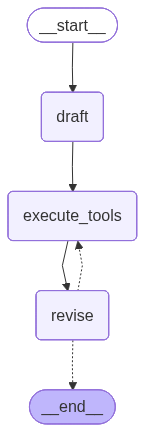

In [92]:
graph_builder.add_conditional_edges("revise", event_loop, ["execute_tools", END])
graph_builder.add_edge(START, "draft")
graph = graph_builder.compile()
graph

In [93]:
events = graph.stream(
    {"messages": [HumanMessage(content="AI Agent가 무엇인가요?")]}, stream_mode="values"
)

for i, step in enumerate(events):
    print(f'Step {i}')
    step["messages"][-1].pretty_print()

Step 0
================================ Human Message =================================

AI Agent가 무엇인가요?
Step 1
================================== Ai Message ==================================
Tool Calls:
  AnswerQuestion (call_Wj7wu6YVYg1e5ugyAuoc9bIQ)
 Call ID: call_Wj7wu6YVYg1e5ugyAuoc9bIQ
  Args:
    answer: AI Agent는 환경을 인식하고, 목표를 세우거나 주어진 목표를 해석한 뒤, 스스로 적절한 행동을 선택해 실행하는 인공지능 시스템입니다. 단순히 질문에 답하는 모델과 달리, AI Agent는 계획 수립, 도구 사용, 외부 정보 검색, 작업 수행, 결과 평가를 반복하면서 목표 달성을 시도할 수 있습니다. 예를 들어 일정 예약, 이메일 분류, 고객 문의 처리, 코드 작성 보조, 데이터 분석 자동화 같은 업무를 여러 단계로 나누어 처리할 수 있습니다. 일반적으로 AI Agent는 입력 이해, 메모리 또는 상태 관리, 의사결정, 행동 실행, 피드백 반영의 요소로 구성됩니다. 최근에는 대형언어모델(LLM)을 중심으로 웹 브라우저, 데이터베이스, API, 소프트웨어 도구와 연결된 에이전트 형태가 많이 활용됩니다. 다만 완전한 자율성을 가진 것은 아니며, 잘못된 판단, 환각, 보안 문제, 권한 남용 같은 위험이 있어 사람의 감독과 제한된 권한 설계가 중요합니다. 따라서 AI Agent는 ‘생각하고 행동하는 자동화된 소프트웨어 조력자’로 이해하면 가장 실용적입니다. 사용자의 현재 요청에 맞춰 보면, 질문 자체는 AI Agent의 개념 설명을 요구했고 추가로 자기반성을 요청했으므로, 정의를 간결하게 제시하면서도 범위와 한계를 함께 설명하는 것이 적절합니다.
    search_queries: ['AI agent defin